In [28]:
import pandas as pd

# File paths (update base path if needed)
trans_path = "small/trans/LI-Small_Trans.csv"
acc_path = "small/account/LI-Small_accounts.csv"
pat_path = "small/patterns/LI-Small_Patterns.txt"

# Load data
transactions = pd.read_csv(trans_path)
accounts = pd.read_csv(acc_path)

# Patterns (try this first)
patterns = pd.read_csv(pat_path, sep=",")  # change sep if needed

# Preview
print("Transactions sample:")
print(transactions.head())

print("\nAccounts sample:")
print(accounts.head())

print("\nPatterns sample:")
print(patterns.head())

Transactions sample:
          Timestamp  From Bank    Account  To Bank  Account.1  \
0  2022/09/01 00:08         11  8000ECA90       11  8000ECA90   
1  2022/09/01 00:21       3402  80021DAD0     3402  80021DAD0   
2  2022/09/01 00:00         11  8000ECA90     1120  8006AA910   
3  2022/09/01 00:16       3814  8006AD080     3814  8006AD080   
4  2022/09/01 00:00         20  8006AD530       20  8006AD530   

   Amount Received Receiving Currency  Amount Paid Payment Currency  \
0       3195403.00          US Dollar   3195403.00        US Dollar   
1          1858.96          US Dollar      1858.96        US Dollar   
2        592571.00          US Dollar    592571.00        US Dollar   
3            12.32          US Dollar        12.32        US Dollar   
4          2941.56          US Dollar      2941.56        US Dollar   

  Payment Format  Is Laundering  
0   Reinvestment              0  
1   Reinvestment              0  
2         Cheque              0  
3   Reinvestment         

In [29]:
transactions.columns = transactions.columns.str.strip()
accounts.columns = accounts.columns.str.strip()
transactions['Timestamp'] = pd.to_datetime(transactions['Timestamp'])
print(transactions.isnull().sum())

Timestamp             0
From Bank             0
Account               0
To Bank               0
Account.1             0
Amount Received       0
Receiving Currency    0
Amount Paid           0
Payment Currency      0
Payment Format        0
Is Laundering         0
dtype: int64


In [30]:
transactions['hour'] = transactions['Timestamp'].dt.hour
transactions['day'] = transactions['Timestamp'].dt.day
transactions['weekday'] = transactions['Timestamp'].dt.weekday

transactions['is_weekend'] = transactions['weekday'].apply(lambda x: 1 if x >= 5 else 0)

In [31]:
transactions['amount'] = transactions['Amount Paid']

In [32]:
transactions = transactions[[
    'Account', 'Account.1',
    'amount',
    'Payment Format',
    'hour', 'day', 'weekday', 'is_weekend',
    'Is Laundering'
]]
transactions['Is Laundering'].value_counts(normalize=True)
transactions.head()

,Account,Account.1,amount,Payment Format,hour,day,weekday,is_weekend,Is Laundering
0,8000ECA90,8000ECA90,3195403.00,Reinvestment,0,1,3,0,0
1,80021DAD0,80021DAD0,1858.96,Reinvestment,0,1,3,0,0
2,8000ECA90,8006AA910,592571.00,Cheque,0,1,3,0,0
3,8006AD080,8006AD080,12.32,Reinvestment,0,1,3,0,0
4,8006AD530,8006AD530,2941.56,Reinvestment,0,1,3,0,0


In [33]:
transactions['Is Laundering'].value_counts(normalize=True)

Is Laundering
0    0.999485
1    0.000515
Name: proportion, dtype: float64

STEP 4: TRAIN-TEST SPLIT + IMBALANCE HANDLING

In [34]:
from sklearn.model_selection import train_test_split

X = transactions.drop(columns=['Is Laundering'])
y = transactions['Is Laundering']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [35]:
X = X.drop(columns=['Account', 'Account.1'])
X = pd.get_dummies(X, columns=['Payment Format'], drop_first=True)
print(X.dtypes)

amount                         float64
hour                             int32
day                              int32
weekday                          int32
is_weekend                       int64
Payment Format_Bitcoin            bool
Payment Format_Cash               bool
Payment Format_Cheque             bool
Payment Format_Credit Card        bool
Payment Format_Reinvestment       bool
Payment Format_Wire               bool
dtype: object


In [36]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(y_train_resampled.value_counts())

Is Laundering
0    5536387
1    5536387
Name: count, dtype: int64


In [37]:
from sklearn.linear_model import LogisticRegression

# Use class_weight='balanced' to handle class imbalance
model = LogisticRegression(max_iter=1000, class_weight='balanced')

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [38]:
y_pred = model.predict(X_test)

In [39]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1382961    1136]
 [    713       0]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1384097
           1       0.00      0.00      0.00       713

    accuracy                           1.00   1384810
   macro avg       0.50      0.50      0.50   1384810
weighted avg       1.00      1.00      1.00   1384810



In [40]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)



In [41]:
# XGBoost Classifier
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix

# Train on original (imbalanced) data for baseline
xgb_baseline = XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=(y_train.value_counts()[0]/y_train.value_counts()[1]), random_state=42)
xgb_baseline.fit(X_train, y_train)

y_pred_xgb = xgb_baseline.predict(X_test)

print('XGBoost Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_xgb))
print('XGBoost Classification Report:')
print(classification_report(y_test, y_pred_xgb))

c:\Users\Aarav Raj\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [21:45:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Confusion Matrix:
[[1254512  129585]
 [    221     492]]
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95   1384097
           1       0.00      0.69      0.01       713

    accuracy                           0.91   1384810
   macro avg       0.50      0.80      0.48   1384810
weighted avg       1.00      0.91      0.95   1384810



In [47]:
# Save Random Forest model + feature list (joblib)
import joblib
features_rf = list(X_train_resampled.columns)  # features used to train rf
joblib.dump(rf, "rf_model.joblib")
joblib.dump(features_rf, "rf_features.pkl")
print("Saved rf_model.joblib and rf_features.pkl")

# Optional: save as pickle (portable alternative)
import pickle
with open("rf_model.pkl", "wb") as f:
    pickle.dump(rf, f)

Saved rf_model.joblib and rf_features.pkl


## Improved XGBoost (better features + threshold tuning)
This version adds account-level aggregated features, trains XGBoost on a downsampled training set (keeps all positives + a fixed ratio of negatives), and selects a decision threshold using the validation precision-recall curve (F2 score, recall-focused).

In [42]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
 )
from xgboost import XGBClassifier

# Build stronger, numeric-only features
tx = transactions.copy()
tx['amount'] = pd.to_numeric(tx['amount'], errors='coerce').fillna(0)
tx['log_amount'] = np.log1p(tx['amount'])
tx['same_account'] = (tx['Account'] == tx['Account.1']).astype(int)

# Sender aggregates
tx['sender_txn_count'] = tx.groupby('Account')['amount'].transform('count').astype('int32')
tx['sender_amt_sum'] = tx.groupby('Account')['amount'].transform('sum')
tx['sender_amt_mean'] = tx.groupby('Account')['amount'].transform('mean')
tx['sender_amt_std'] = tx.groupby('Account')['amount'].transform('std').fillna(0)
tx['sender_unique_receivers'] = tx.groupby('Account')['Account.1'].transform('nunique').astype('int32')

# Receiver aggregates
tx['receiver_txn_count'] = tx.groupby('Account.1')['amount'].transform('count').astype('int32')
tx['receiver_amt_sum'] = tx.groupby('Account.1')['amount'].transform('sum')
tx['receiver_amt_mean'] = tx.groupby('Account.1')['amount'].transform('mean')
tx['receiver_amt_std'] = tx.groupby('Account.1')['amount'].transform('std').fillna(0)
tx['receiver_unique_senders'] = tx.groupby('Account.1')['Account'].transform('nunique').astype('int32')

# Features/target
X2 = tx.drop(columns=['Is Laundering', 'Account', 'Account.1'])
y2 = tx['Is Laundering']

# One-hot encode categorical column(s)
if 'Payment Format' in X2.columns:
    X2 = pd.get_dummies(X2, columns=['Payment Format'], drop_first=True)

X2 = X2.replace([np.inf, -np.inf], 0).fillna(0)

# Train/test split (test remains realistic, imbalanced)
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
 )

# Validation split for early stopping + threshold selection
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train2, y_train2, test_size=0.2, random_state=42, stratify=y_train2
 )

# Downsample NEGATIVES for training only (keeps all positives)
neg_to_pos_ratio = 50  # try 20, 50, 100 depending on desired precision/recall
pos_idx = y_tr[y_tr == 1].index
neg_idx_all = y_tr[y_tr == 0].index
neg_keep = min(len(neg_idx_all), len(pos_idx) * neg_to_pos_ratio)
neg_idx = y_tr.loc[neg_idx_all].sample(n=neg_keep, random_state=42).index
sel_idx = pos_idx.union(neg_idx)

X_tr_ds = X_tr.loc[sel_idx]
y_tr_ds = y_tr.loc[sel_idx]

pos_weight = (y_tr_ds == 0).sum() / max((y_tr_ds == 1).sum(), 1)
print('Training distribution (downsampled):')
print(y_tr_ds.value_counts())
print('scale_pos_weight:', float(pos_weight))

# Tuned-ish XGBoost config + early stopping (native API)
import xgboost as xgb
params = {
    'objective': 'binary:logistic',
    'learning_rate': 0.03,
    'max_depth': 6,
    'min_child_weight': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'lambda': 1.0,
    'alpha': 0.0,
    'gamma': 0.0,
    'scale_pos_weight': float(pos_weight),
    'eval_metric': 'aucpr',
    'tree_method': 'hist',
    'seed': 42,
}

# Prepare DMatrix and train with early stopping
dtrain = xgb.DMatrix(X_tr_ds, label=y_tr_ds)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test2)
bst = xgb.train(
    params,
    dtrain,
    num_boost_round=5000,
    evals=[(dval, 'validation')],
    early_stopping_rounds=100,
    verbose_eval=200,
)

# Use best iteration for predictions
val_proba = bst.predict(dval, iteration_range=(0, bst.best_iteration + 1))
test_proba = bst.predict(dtest, iteration_range=(0, bst.best_iteration + 1))

# Pick a probability threshold on validation (recall-focused)
# `val_proba` was produced by `bst.predict(dval, ...)` above
val_ap = average_precision_score(y_val, val_proba)
val_auc = roc_auc_score(y_val, val_proba)
prec, rec, thresh = precision_recall_curve(y_val, val_proba)

# F2 score computed at each threshold (skip first point which has no threshold)
prec_t, rec_t = prec[1:], rec[1:]
thresh_t = thresh
f2 = (5 * prec_t * rec_t) / (4 * prec_t + rec_t + 1e-12)
best_i = int(np.argmax(f2))
best_thresh = float(thresh_t[best_i])

print('\nValidation metrics:')
print('PR-AUC:', float(val_ap))
print('ROC-AUC:', float(val_auc))
print('Chosen threshold (max F2):', best_thresh)
print('At threshold -> precision:', float(prec_t[best_i]), 'recall:', float(rec_t[best_i]))

# Evaluate on test using that threshold
# `test_proba` was produced by `bst.predict(dtest, ...)` above
y_pred2 = (test_proba >= best_thresh).astype(int)

print('\nXGBoost (engineered features) Confusion Matrix:')
print(confusion_matrix(y_test2, y_pred2))
print('\nXGBoost (engineered features) Classification Report:')
print(classification_report(y_test2, y_pred2, digits=4))

print('\nTest PR-AUC:', float(average_precision_score(y_test2, test_proba)))
print('Test ROC-AUC:', float(roc_auc_score(y_test2, test_proba)))

Training distribution (downsampled):
Is Laundering
0    114100
1      2282
Name: count, dtype: int64
scale_pos_weight: 50.0
[0]	validation-aucpr:0.01602
[200]	validation-aucpr:0.05413
[400]	validation-aucpr:0.07849
[600]	validation-aucpr:0.08797
[800]	validation-aucpr:0.09587
[1000]	validation-aucpr:0.10073
[1200]	validation-aucpr:0.10413
[1400]	validation-aucpr:0.10803
[1505]	validation-aucpr:0.10774

Validation metrics:
PR-AUC: 0.10880937451854862
ROC-AUC: 0.9744182826652227
Chosen threshold (max F2): 0.9742249846458435
At threshold -> precision: 0.09286412512218964 recall: 0.3333333333333333

XGBoost (engineered features) Confusion Matrix:
[[1381692    2405]
 [    470     243]]

XGBoost (engineered features) Classification Report:
              precision    recall  f1-score   support

           0     0.9997    0.9983    0.9990   1384097
           1     0.0918    0.3408    0.1446       713

    accuracy                         0.9979   1384810
   macro avg     0.5457    0.6695    0

In [43]:
rf.fit(X_train_resampled, y_train_resampled)

y_pred_rf = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))




[[1369457   14640]
 [    656      57]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99   1384097
           1       0.00      0.08      0.01       713

    accuracy                           0.99   1384810
   macro avg       0.50      0.53      0.50   1384810
weighted avg       1.00      0.99      0.99   1384810



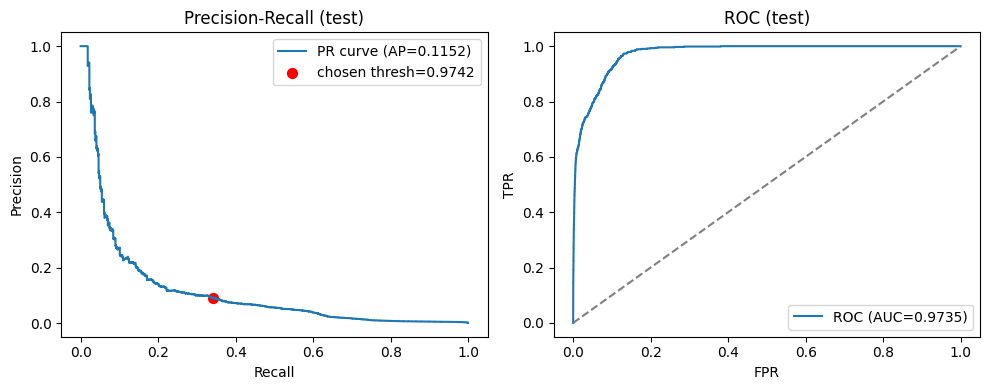

Test precision at chosen threshold: 0.09176737160120846
Test recall at chosen threshold: 0.34081346423562414
Confusion matrix at chosen threshold:
[[1381692    2405]
 [    470     243]]


In [44]:
# Evaluation: PR / ROC plots and test threshold point
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, auc, precision_score, recall_score

# Precision-Recall curve on test set
prec, rec, thr = precision_recall_curve(y_test2, test_proba)
pr_auc = average_precision_score(y_test2, test_proba)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(rec, prec, label=f'PR curve (AP={pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall (test)')
# mark chosen threshold point if available
if len(thr) > 0:
    # thr aligns with prec[1:], rec[1:]
    prec_t, rec_t = prec[1:], rec[1:]
    idx = int((np.abs(thr - best_thresh)).argmin())
    plt.scatter(rec_t[idx], prec_t[idx], color='red', s=50, label=f'chosen thresh={best_thresh:.4f}')
    plt.legend()

# ROC curve on test set
fpr, tpr, _ = roc_curve(y_test2, test_proba)
roc_auc = roc_auc_score(y_test2, test_proba)
plt.subplot(1,2,2)
plt.plot(fpr, tpr, label=f'ROC (AUC={roc_auc:.4f})')
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC (test)')
plt.legend()
plt.tight_layout()
plt.show()

# Print precision/recall at chosen threshold on test set
y_pred_at_thresh = (test_proba >= best_thresh).astype(int)
print('Test precision at chosen threshold:', precision_score(y_test2, y_pred_at_thresh))
print('Test recall at chosen threshold:', recall_score(y_test2, y_pred_at_thresh))
print('Confusion matrix at chosen threshold:')
print(confusion_matrix(y_test2, y_pred_at_thresh))

In [45]:
# SHAP explanation (optional)
try:
    import shap
    print('SHAP version:', shap.__version__)
    # Use TreeExplainer for xgboost Booster
    explainer = shap.TreeExplainer(bst)
    # Convert X_test2 to DataFrame if it's not already
    Xshap = X_test2.copy() if hasattr(X_test2, 'copy') else pd.DataFrame(X_test2)
    shap_values = explainer.shap_values(Xshap)
    # Summary plot (bar)
    shap.summary_plot(shap_values, Xshap, plot_type='bar')
except Exception as e:
    print('SHAP not available or failed to run:', str(e))
    print('To enable SHAP, install it with `pip install shap` and rerun this cell.')

SHAP not available or failed to run: No module named 'shap'
To enable SHAP, install it with `pip install shap` and rerun this cell.


In [46]:
# Save model and feature list
import joblib
# save xgboost Booster to JSON (portable)
bst.save_model('xgb_bst.json')
# save feature names for later mapping
features = list(X_tr_ds.columns)
joblib.dump(features, 'xgb_features.pkl')
print('Saved xgb_bst.json and xgb_features.pkl in current directory')

Saved xgb_bst.json and xgb_features.pkl in current directory
